# <center> Homework 132

In [1]:
import tf_model 
import tf_data
from importlib import reload
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import time

2026-02-27 08:23:29.846688: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-27 08:23:31.159145: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-27 08:23:35.194432: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
2026-02-27 08:23:37.406229: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit

## Load Data

In [2]:
path = Path("datasets/CTA_-_Ridership_-_Daily_Boarding_Totals_20260211.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"] 
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1) 
df = df.drop_duplicates() 

df['bus'] = df['bus'].str.replace(",", "").astype(float)
df['rail'] = df['rail'].str.replace(",", "").astype(float)

In [3]:
df_mulvar = df[["bus", "rail"]] / 1e6
df_mulvar["next_day_type"] = df["day_type"].shift(-1)
df_mulvar = pd.get_dummies(df_mulvar).astype(np.float32)

df_mulvar.head()

,bus,rail,next_day_type_A,next_day_type_U,next_day_type_W
date,,,,,
2001-01-01,0.297192,0.126455,0.0,0.0,1.0
2001-01-02,0.780827,0.501952,0.0,0.0,1.0
2001-01-03,0.824923,0.536432,0.0,0.0,1.0
2001-01-04,0.870021,0.550011,0.0,0.0,1.0
2001-01-05,0.890426,0.557917,1.0,0.0,0.0


In [4]:
mulvar_train = df_mulvar["2010-01":"2018-12"]
mulvar_valid = df_mulvar["2019-01":"2019-05"]
mulvar_test = df_mulvar["2019-06":'2019-12']

In [5]:
reload(tf_data)
from tf_data import timeseries_dataset_from_array

frame_len = 56

train_ds = timeseries_dataset_from_array(mulvar_train,
                                        targets=mulvar_train[['rail']][frame_len:],
                                        sequence_length=frame_len,
                                        batch_size=32,
                                        shuffle=True)

test_ds  = timeseries_dataset_from_array(mulvar_valid,
                                        targets=mulvar_valid[['rail']][frame_len:],
                                        sequence_length=frame_len,
                                        batch_size=32)

## Task 1 
да се имплементират класовете LSTMCell и LSTM

### LSTM Layer

In [7]:
reload(tf_model)
from tf_model import Sequential, Dense, Input, LSTM, Adam, Bidirectional

LSTM_model_cus = Sequential([
    Input([None, 5]),
    Bidirectional(LSTM(32)),
    Dense(1)
])

LSTM_model_cus.compile(loss='mae', optimizer=Adam(0.01), metrics=['mape'])
LSTM_model_cus.fit(train_ds, epochs=20, validation_data=(test_ds))

Epoch 1/20


0it [00:00, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, activation, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, activation, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verb

101it [00:40,  2.49it/s]


    - loss: 0.076 - meanabsolutepercentageerror: 0.144
    - val_loss: 0.030 - val_meanabsolutepercentageerror: 0.069
    - Learning Rate: 0.01
Epoch 2/20


...

    - loss: 0.035 - meanabsolutepercentageerror: 0.066
    - val_loss: 0.027 - val_meanabsolutepercentageerror: 0.052
    - Learning Rate: 0.01
Epoch 12/20


101it [00:25,  3.95it/s]


    - loss: 0.034 - meanabsolutepercentageerror: 0.063
    - val_loss: 0.041 - val_meanabsolutepercentageerror: 0.087
    - Learning Rate: 0.01
Epoch 13/20


45it [00:19,  2.29it/s]


KeyboardInterrupt: 

('MAPE', np.float32(0.06109132), 'MAE', 0.032)

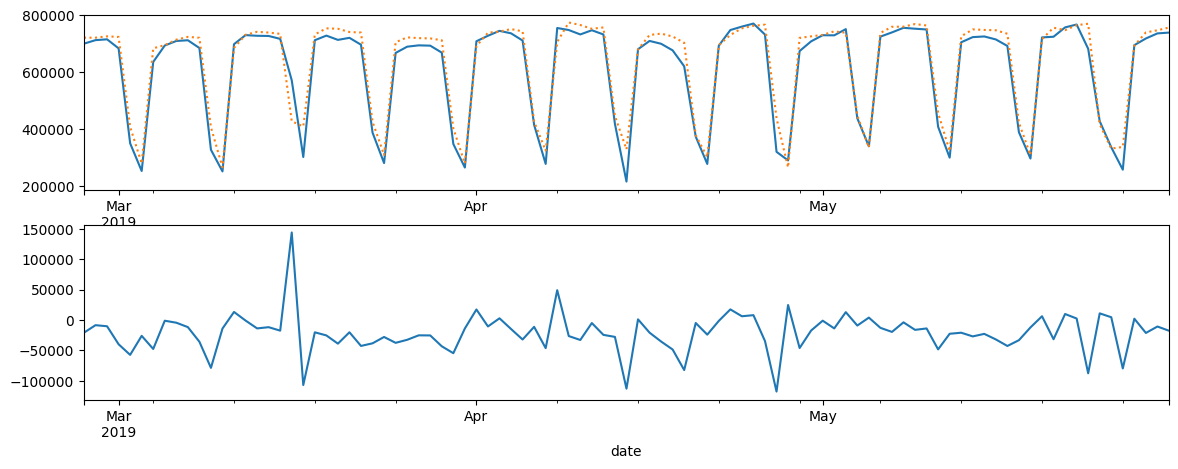

In [41]:
y_true = mulvar_valid['rail'].iloc[frame_len:] * 1e6
cus_pred = pd.Series(np.ravel(LSTM_model_cus.predict(test_ds).numpy()), y_true.index) * 1e6

fig, ax = plt.subplots(2, 1, figsize=(14, 5))
diff = (y_true - cus_pred)

y_true.plot(ax=ax[0])
cus_pred.plot(ax=ax[0], style=':')

diff.plot(ax=ax[1])

mape_cus = np.abs(diff / y_true).mean()
'MAPE', mape_cus, 'MAE', 0.033

In [52]:
frame_len = 56

train_ds_org = tf.keras.utils.timeseries_dataset_from_array(mulvar_train,
                                        targets=mulvar_train['rail'][frame_len:],
                                        sequence_length=frame_len,
                                        batch_size=32,
                                        shuffle=True)

test_ds_org  = tf.keras.utils.timeseries_dataset_from_array(mulvar_valid,
                                        targets=mulvar_valid['rail'][frame_len:],
                                        sequence_length=frame_len,
                                        batch_size=32)

In [18]:
LSTM_model = tf.keras.Sequential([
    tf.keras.layers.Input([None, 5]),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(1)
])

LSTM_model.compile(loss='mae', optimizer=tf.keras.optimizers.Adam(0.01), metrics=['mape'])
LSTM_model.fit(train_ds, epochs=20, validation_data=(test_ds))

Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.0825 - mape: 15.9709 - val_loss: 0.0355 - val_mape: 7.7821
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0411 - mape: 7.9308 - val_loss: 0.0491 - val_mape: 10.6328
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0358 - mape: 6.9071 - val_loss: 0.0277 - val_mape: 6.0289
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0386 - mape: 7.2836 - val_loss: 0.0307 - val_mape: 5.5811
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0336 - mape: 6.4476 - val_loss: 0.0320 - val_mape: 6.7233
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0316 - mape: 6.1074 - val_loss: 0.0369 - val_mape: 8.2860
Epoch 7/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0353 - mape: 6.6331 - val_loss: 0.0289 - val_mape: 6.9393
Epoch 8/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0334 - mape: 6.3816 - val_loss: 0.0385 - val_mape: 8.3232
Epoch 9/20
101/101 ━━━━━━━━━━━

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


('MAPE', np.float32(0.053663418), 'MAE', 0.0296)

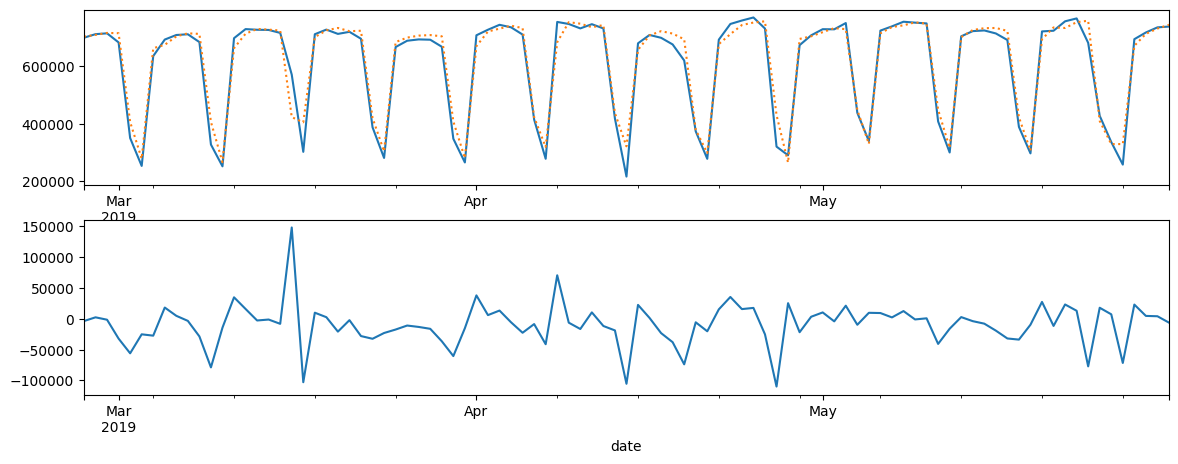

In [24]:
y_true = mulvar_valid['rail'].iloc[frame_len:] * 1e6
org_pred = pd.Series(np.ravel(LSTM_model.predict(test_ds)), y_true.index) * 1e6

fig, ax = plt.subplots(2, 1, figsize=(14, 5))
diff = (y_true - org_pred)

y_true.plot(ax=ax[0])
org_pred.plot(ax=ax[0], style=':')

diff.plot(ax=ax[1])

mape_org = np.abs(diff / y_true).mean()
'MAPE', mape_org, 'MAE', 0.0296

### LSTM Cell

In [45]:
reload(tf_model)
from tf_model import Sequential, Dense, Input, LSTMCell, RNN, Adam

LSTMCell_model_cus = Sequential([
    Input([None, 5]),
    RNN(LSTMCell(32)),
    Dense(1)
])

LSTMCell_model_cus.compile(loss='mae', optimizer=Adam(0.01), metrics=['mape'])
LSTMCell_model_cus.fit(train_ds, epochs=20, validation_data=(test_ds))

Epoch 1/20


0it [00:00, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, activation, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, activation, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verb

101it [00:21,  4.79it/s]


    - loss: 0.071 - meanabsolutepercentageerror: 0.133
    - val_loss: 0.040 - val_meanabsolutepercentageerror: 0.088
    - Learning Rate: 0.01
Epoch 2/20


...

    - loss: 0.032 - meanabsolutepercentageerror: 0.061
    - val_loss: 0.024 - val_meanabsolutepercentageerror: 0.055
    - Learning Rate: 0.01
Epoch 19/20


101it [00:11,  8.67it/s]


    - loss: 0.031 - meanabsolutepercentageerror: 0.059
    - val_loss: 0.028 - val_meanabsolutepercentageerror: 0.059
    - Learning Rate: 0.01
Epoch 20/20


101it [00:11,  8.65it/s]


    - loss: 0.032 - meanabsolutepercentageerror: 0.062
    - val_loss: 0.040 - val_meanabsolutepercentageerror: 0.079
    - Learning Rate: 0.01


('MAPE', np.float32(0.07969125), 'MAE', 0.032)

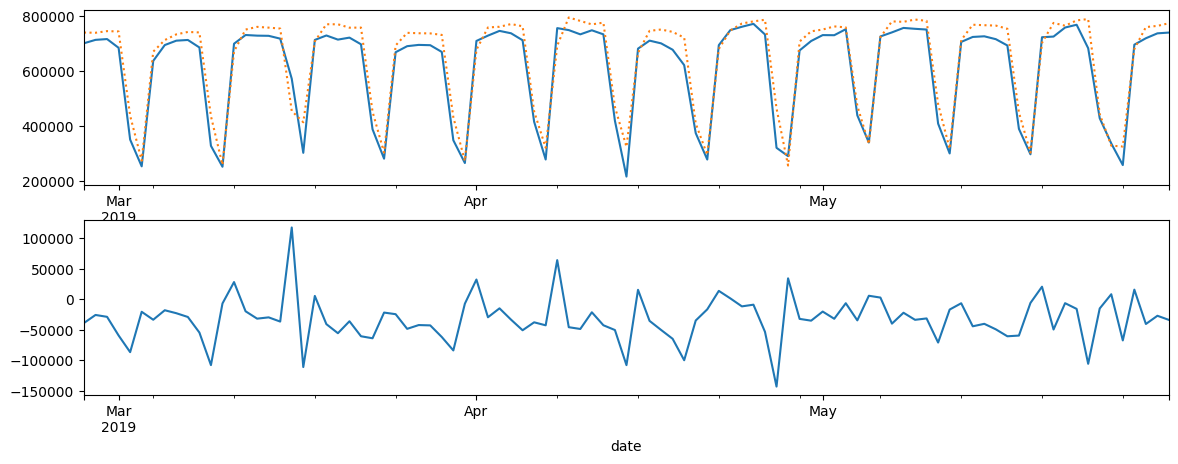

In [46]:
y_true = mulvar_valid['rail'].iloc[frame_len:] * 1e6
cus_pred = pd.Series(np.ravel(LSTMCell_model_cus.predict(test_ds).numpy()), y_true.index) * 1e6

fig, ax = plt.subplots(2, 1, figsize=(14, 5))
diff = (y_true - cus_pred)

y_true.plot(ax=ax[0])
cus_pred.plot(ax=ax[0], style=':')

diff.plot(ax=ax[1])

mape_cus = np.abs(diff / y_true).mean()
'MAPE', mape_cus, 'MAE', 0.032

## Task 2
да се имплементират класовете GRU и GRUCell

### GRU Layer

In [48]:
reload(tf_model)
from tf_model import Sequential, Dense, Input, GRU, Adam

GRU_model_cus = Sequential([
    Input([None, 5]),
    GRU(32),
    Dense(1)
])

GRU_model_cus.compile(loss='mae', optimizer=Adam(0.01), metrics=['mape'])
GRU_model_cus.fit(train_ds, epochs=20, validation_data=(test_ds))

Epoch 1/20


0it [00:00, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, activation, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, activation, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verb

101it [00:17,  5.74it/s]


    - loss: 0.088 - meanabsolutepercentageerror: 0.163
    - val_loss: 0.028 - val_meanabsolutepercentageerror: 0.053
    - Learning Rate: 0.01
Epoch 2/20


...

    - loss: 0.034 - meanabsolutepercentageerror: 0.064
    - val_loss: 0.047 - val_meanabsolutepercentageerror: 0.099
    - Learning Rate: 0.01
Epoch 19/20


101it [00:10,  9.20it/s]


    - loss: 0.034 - meanabsolutepercentageerror: 0.063
    - val_loss: 0.049 - val_meanabsolutepercentageerror: 0.090
    - Learning Rate: 0.01
Epoch 20/20


101it [00:11,  9.16it/s]


    - loss: 0.031 - meanabsolutepercentageerror: 0.058
    - val_loss: 0.023 - val_meanabsolutepercentageerror: 0.050
    - Learning Rate: 0.01


('MAPE', np.float32(0.050012045), 'MAE', 23000.0)

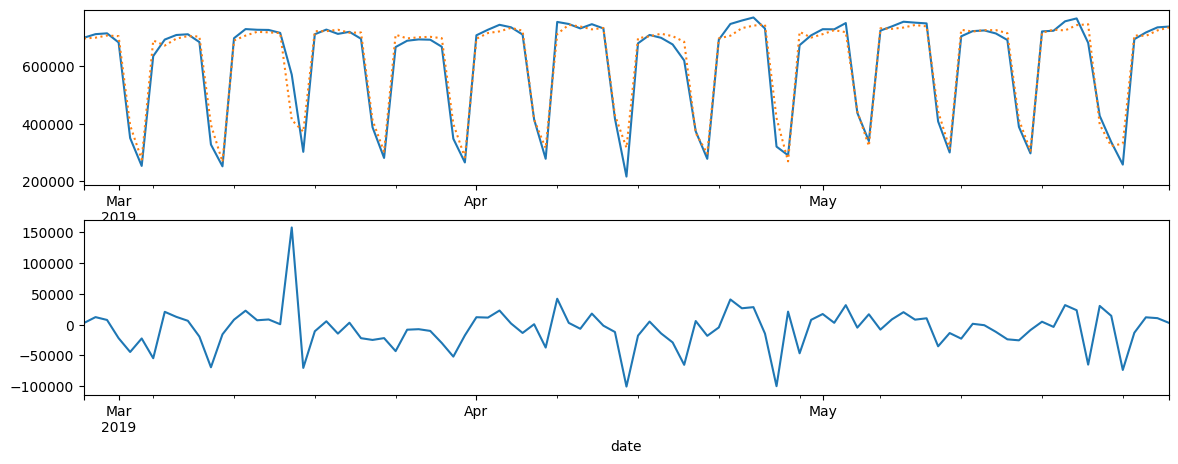

In [50]:
y_true = mulvar_valid['rail'].iloc[frame_len:] * 1e6
cus_pred = pd.Series(np.ravel(GRU_model_cus.predict(test_ds).numpy()), y_true.index) * 1e6

fig, ax = plt.subplots(2, 1, figsize=(14, 5))
diff = (y_true - cus_pred)

y_true.plot(ax=ax[0])
cus_pred.plot(ax=ax[0], style=':')

diff.plot(ax=ax[1])

mape_cus = np.abs(diff / y_true).mean()
'MAPE', mape_cus, 'MAE', 0.023 * 1e6

In [55]:
GRU_model = tf.keras.Sequential([
    tf.keras.layers.Input([None, 5]),
    tf.keras.layers.GRU(32),
    tf.keras.layers.Dense(1)
])

GRU_model.compile(loss='mae', optimizer=tf.keras.optimizers.Adam(0.01), metrics=['mape'])
GRU_model.fit(train_ds_org, epochs=20, validation_data=(test_ds_org))

Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - loss: 0.0542 - mape: 10.1187 - val_loss: 0.0334 - val_mape: 6.0047
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 0.0377 - mape: 7.2424 - val_loss: 0.0223 - val_mape: 4.5440
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 0.0324 - mape: 6.2541 - val_loss: 0.0259 - val_mape: 5.6576
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - loss: 0.0360 - mape: 6.8390 - val_loss: 0.0315 - val_mape: 5.9001
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 0.0358 - mape: 6.8136 - val_loss: 0.0256 - val_mape: 5.3926
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 0.0324 - mape: 6.3569 - val_loss: 0.0238 - val_mape: 5.3825
Epoch 7/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0345 - mape: 6.5655 - val_loss: 0.0381 - val_mape: 7.1016
Epoch 8/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 0.0348 - mape: 6.6187 - val_loss: 0.0232 - val_mape: 4.7165
Epoch 9/20
101/101 ━━━━━━━━━━━

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step


('MAPE', np.float32(0.053925827), 'MAE', 28300.0)

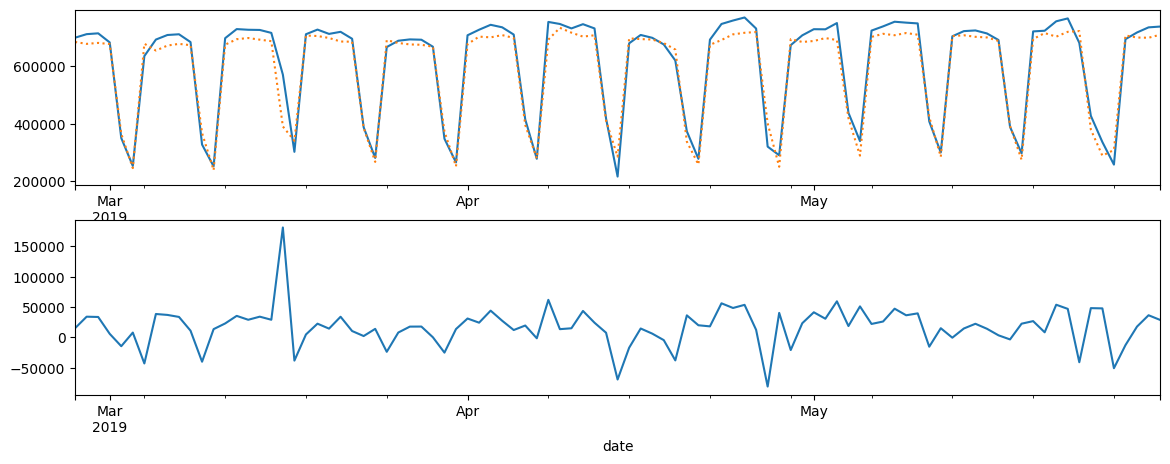

In [56]:
y_true = mulvar_valid['rail'].iloc[frame_len:] * 1e6
org_pred = pd.Series(np.ravel(GRU_model.predict(test_ds_org)), y_true.index) * 1e6

fig, ax = plt.subplots(2, 1, figsize=(14, 5))
diff = (y_true - org_pred)

y_true.plot(ax=ax[0])
org_pred.plot(ax=ax[0], style=':')

diff.plot(ax=ax[1])

mape_org = np.abs(diff / y_true).mean()
'MAPE', mape_org, 'MAE', 0.0283 * 1e6

### GRU Cell

In [58]:
reload(tf_model)
from tf_model import Sequential, Dense, Input, GRUCell, RNN, Adam

GRUCell_model_cus = Sequential([
    Input([None, 5]),
    RNN(GRUCell(32)),
    Dense(1)
])

GRUCell_model_cus.compile(loss='mae', optimizer=Adam(0.01), metrics=['mape'])
GRUCell_model_cus.fit(train_ds, epochs=20, validation_data=(test_ds))

Epoch 1/20


0it [00:00, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, activation, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, activation, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verb

101it [00:20,  5.03it/s]


    - loss: 0.084 - meanabsolutepercentageerror: 0.155
    - val_loss: 0.031 - val_meanabsolutepercentageerror: 0.064
    - Learning Rate: 0.01
Epoch 2/20


...

    - loss: 0.035 - meanabsolutepercentageerror: 0.066
    - val_loss: 0.039 - val_meanabsolutepercentageerror: 0.071
    - Learning Rate: 0.01
Epoch 19/20


101it [00:11,  8.65it/s]


    - loss: 0.031 - meanabsolutepercentageerror: 0.059
    - val_loss: 0.021 - val_meanabsolutepercentageerror: 0.042
    - Learning Rate: 0.01
Epoch 20/20


101it [00:08, 12.02it/s]


    - loss: 0.031 - meanabsolutepercentageerror: 0.058
    - val_loss: 0.029 - val_meanabsolutepercentageerror: 0.055
    - Learning Rate: 0.01


('MAPE', np.float32(0.055127725), 'MAE', np.float32(28576.977))

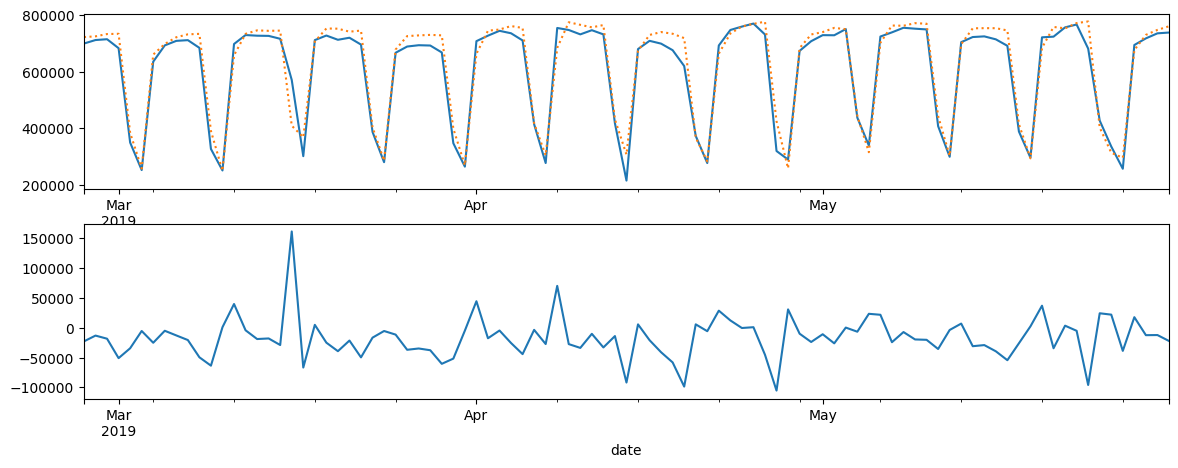

In [59]:
y_true = mulvar_valid['rail'].iloc[frame_len:] * 1e6
cus_pred = pd.Series(np.ravel(GRUCell_model_cus.predict(test_ds).numpy()), y_true.index) * 1e6

fig, ax = plt.subplots(2, 1, figsize=(14, 5))
diff = (y_true - cus_pred)

y_true.plot(ax=ax[0])
cus_pred.plot(ax=ax[0], style=':')

diff.plot(ax=ax[1])

mape_cus = np.abs(diff / y_true).mean()
'MAPE', mape_cus, 'MAE', np.abs(diff).mean()

## Task 3
да се сравнят performance и врме за обучение на модели за пресказване на поредици:

### RNN

In [62]:
SimpleRNN_model = tf.keras.Sequential([
    tf.keras.layers.Input([None, 5]),
    tf.keras.layers.SimpleRNN(64, return_sequences=True),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1)
])

SimpleRNN_model.compile(loss=tf.keras.losses.Huber(), 
                        optimizer=tf.keras.optimizers.Adam(0.01), 
                        metrics=['mae'])

s = time.time()
SimpleRNN_model.fit(train_ds_org, epochs=20, validation_data=(test_ds_org))
SimpleRNN_fittime = time.time() - s

SimpleRNN_fittime

Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - loss: 0.0221 - mae: 0.1038 - val_loss: 6.7709e-04 - val_mae: 0.0255
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 0.0027 - mae: 0.0554 - val_loss: 0.0027 - val_mae: 0.0664
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 0.0025 - mae: 0.0531 - val_loss: 8.4857e-04 - val_mae: 0.0298
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 0.0024 - mae: 0.0521 - val_loss: 7.1527e-04 - val_mae: 0.0279
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.0024 - mae: 0.0524 - val_loss: 7.1616e-04 - val_mae: 0.0268
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0019 - mae: 0.0461 - val_loss: 6.6080e-04 - val_mae: 0.0265
Epoch 7/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.0018 - mae: 0.0441 - val_loss: 6.5433e-04 - val_mae: 0.0253
Epoch 8/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0020 - mae: 0.0472 - val_loss: 7.7806e-04 - val_mae: 0.0278
Epoch 9/20
101/101 

97.75075507164001

### LSTM

In [63]:
LSTM_model = tf.keras.Sequential([
    tf.keras.layers.Input([None, 5]),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(1)
])

LSTM_model.compile(loss=tf.keras.losses.Huber(), 
                        optimizer=tf.keras.optimizers.Adam(0.01), 
                        metrics=['mae'])

s = time.time()
LSTM_model.fit(train_ds_org, epochs=20, validation_data=(test_ds_org))
LSTM_fittime = time.time() - s

LSTM_fittime

Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - loss: 0.0103 - mae: 0.0934 - val_loss: 8.4063e-04 - val_mae: 0.0316
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0021 - mae: 0.0476 - val_loss: 7.6682e-04 - val_mae: 0.0289
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - loss: 0.0016 - mae: 0.0398 - val_loss: 6.8929e-04 - val_mae: 0.0268
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - loss: 0.0019 - mae: 0.0453 - val_loss: 8.3317e-04 - val_mae: 0.0309
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - loss: 0.0013 - mae: 0.0352 - val_loss: 9.5011e-04 - val_mae: 0.0336
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - loss: 0.0013 - mae: 0.0359 - val_loss: 7.8477e-04 - val_mae: 0.0303
Epoch 7/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - loss: 0.0013 - mae: 0.0355 - val_loss: 9.9123e-04 - val_mae: 0.0343
Epoch 8/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step - loss: 0.0012 - mae: 0.0343 - val_loss: 6.8819e-04 - val_mae: 0.0268
Epoch 9/20
101/

139.28450441360474

### GRU

In [64]:
GRU_model = tf.keras.Sequential([
    tf.keras.layers.Input([None, 5]),
    tf.keras.layers.GRU(64, return_sequences=True),
    tf.keras.layers.GRU(32),
    tf.keras.layers.Dense(1)
])

GRU_model.compile(loss=tf.keras.losses.Huber(), 
                        optimizer=tf.keras.optimizers.Adam(0.01), 
                        metrics=['mae'])

s = time.time()
GRU_model.fit(train_ds_org, epochs=20, validation_data=(test_ds_org))
GRU_fittime = time.time() - s

GRU_fittime

Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - loss: 0.0127 - mae: 0.0878 - val_loss: 6.9509e-04 - val_mae: 0.0272
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 0.0013 - mae: 0.0352 - val_loss: 7.6288e-04 - val_mae: 0.0283
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 0.0012 - mae: 0.0335 - val_loss: 7.6050e-04 - val_mae: 0.0274
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 0.0012 - mae: 0.0349 - val_loss: 7.1273e-04 - val_mae: 0.0279
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - loss: 0.0013 - mae: 0.0348 - val_loss: 8.0495e-04 - val_mae: 0.0284
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 0.0012 - mae: 0.0343 - val_loss: 8.9341e-04 - val_mae: 0.0299
Epoch 7/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 0.0013 - mae: 0.0361 - val_loss: 8.9163e-04 - val_mae: 0.0310
Epoch 8/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - loss: 0.0012 - mae: 0.0330 - val_loss: 6.7167e-04 - val_mae: 0.0259
Epoch 9/20
101/

145.19827604293823

### Conv1

In [ ]:
wavenet_model = tf.keras.Sequential()
wavenet_model.add(tf.keras.layers.Input(shape=[None, 5]))

for rate in (1, 2, 4, 8) * 2: # (1, 2, 4, 8, 1, 2, 4, 8)
    wavenet_model.add(tf.keras.layers.Conv1D(
        filters=32, kernel_size=2, padding="causal", activation="relu",
        dilation_rate=rate))

wavenet_model.add(tf.keras.layers.GlobalAveragePooling1D())
wavenet_model.add(tf.keras.layers.Dense(1))

In [68]:
wavenet_model.compile(loss=tf.keras.losses.Huber(), 
                        optimizer=tf.keras.optimizers.Adam(0.01), 
                        metrics=['mae'])

s = time.time()
wavenet_model.fit(train_ds_org, epochs=20, validation_data=(test_ds_org))
wavenet_fittime = time.time() - s

wavenet_fittime

Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 0.0344 - mae: 0.1927 - val_loss: 0.0158 - val_mae: 0.1595
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0119 - mae: 0.1262 - val_loss: 0.0073 - val_mae: 0.1033
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0061 - mae: 0.0774 - val_loss: 0.0046 - val_mae: 0.0639
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0061 - mae: 0.0782 - val_loss: 0.0043 - val_mae: 0.0596
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0054 - mae: 0.0702 - val_loss: 0.0041 - val_mae: 0.0599
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0053 - mae: 0.0700 - val_loss: 0.0037 - val_mae: 0.0639
Epoch 7/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0049 - mae: 0.0665 - val_loss: 0.0037 - val_mae: 0.0595
Epoch 8/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0047 - mae: 0.0647 - val_loss: 0.0103 - val_mae: 0.1190
Epoch 9/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms

78.28216600418091

### Results

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step


,MAPE,MAE,Fit Time
SimpleRNN,0.074448,34765.511719,97.750755
LSTM,0.052637,25831.748047,139.284504
GRU,0.056086,25559.259766,145.198276
Wavenet,0.103176,49486.132812,78.282166


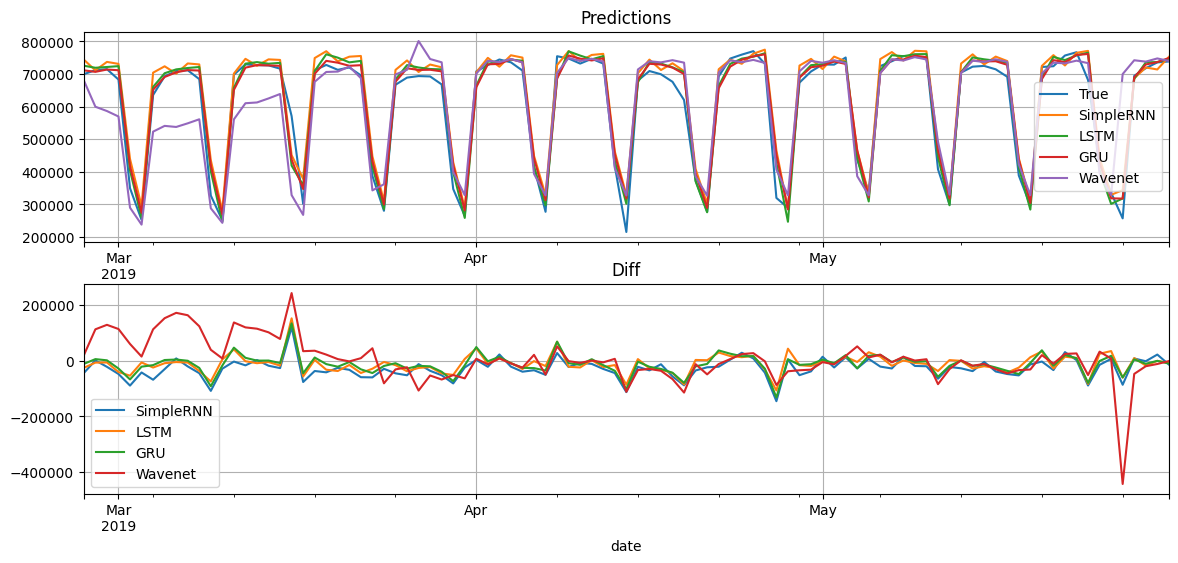

In [69]:
y_true = mulvar_valid['rail'].iloc[frame_len:] * 1e6

simple_pred  = pd.Series(np.ravel(SimpleRNN_model.predict(test_ds_org)), y_true.index) * 1e6
LSTM_pred    = pd.Series(np.ravel(LSTM_model.predict(test_ds_org)), y_true.index) * 1e6
GRU_pred     = pd.Series(np.ravel(GRU_model.predict(test_ds_org)), y_true.index) * 1e6
wavenet_pred = pd.Series(np.ravel(wavenet_model.predict(test_ds_org)), y_true.index) * 1e6

simple_diff  = y_true - simple_pred
LSTM_diff    = y_true - LSTM_pred
GRU_diff     = y_true - GRU_pred
wavenet_diff = y_true - wavenet_pred

fig, ax = plt.subplots(2, 1, figsize=(14, 6))

y_true.plot(ax=ax[0], label='True')
simple_pred.plot(ax=ax[0], label='SimpleRNN')
LSTM_pred.plot(ax=ax[0], label='LSTM')
GRU_pred.plot(ax=ax[0], label='GRU')
wavenet_pred.plot(ax=ax[0], label='Wavenet')

ax[0].set_title('Predictions')
ax[0].legend()
ax[0].grid()

simple_diff.plot(ax=ax[1], label='SimpleRNN')
LSTM_diff.plot(ax=ax[1], label='LSTM')
GRU_diff.plot(ax=ax[1], label='GRU')
wavenet_diff.plot(ax=ax[1], label='Wavenet')

ax[1].set_title('Diff')
ax[1].legend()
ax[1].grid()

simple_mape  = np.abs(simple_diff / y_true).mean()
LSTM_mape    = np.abs(LSTM_diff / y_true).mean()
GRU_mape     = np.abs(GRU_diff / y_true).mean()
wavenet_mape = np.abs(wavenet_diff / y_true).mean()

simple_mae  = np.abs(simple_diff).mean()
LSTM_mae    = np.abs(LSTM_diff).mean()
GRU_mae     = np.abs(GRU_diff).mean()
wavenet_mae = np.abs(wavenet_diff).mean()

pd.DataFrame([
    [simple_mape, simple_mae, SimpleRNN_fittime],
    [LSTM_mape, LSTM_mae, LSTM_fittime],
    [GRU_mape, GRU_mae, GRU_fittime],
    [wavenet_mape, wavenet_mae, wavenet_fittime],
], index=['SimpleRNN', 'LSTM', 'GRU', 'Wavenet'], columns=['MAPE', 'MAE', 'Fit Time'])

## Task 4
всички нови layer-и да ползват @tf функции. да се тества колко се подобрява бързодействеито

In [100]:
seq_length = 56

time_data = []
data_len = len(mulvar_train)
for i in range(data_len - seq_length):
    start = i
    end   = start + seq_length

    part = mulvar_train.iloc[start:end].to_numpy()
    time_data.append(part)

X_train = tf.convert_to_tensor(time_data)
y_train = tf.convert_to_tensor(mulvar_train[['rail']].iloc[seq_length:].to_numpy())

time_data = []
data_len = len(mulvar_valid)
for i in range(data_len - seq_length):
    start = i
    end   = start + seq_length

    part = mulvar_valid.iloc[start:end].to_numpy()
    time_data.append(part)

X_test = tf.convert_to_tensor(time_data)
y_test = tf.convert_to_tensor(mulvar_valid[['rail']].iloc[seq_length:].to_numpy())

In [147]:
reload(tf_model)
from tf_model import Sequential, Dense, Input, Adam

def test_fit_time(layer):
    model = Sequential([
        Input([None, 5]),
        layer,
        Dense(1)
    ])

    model.compile(loss='mae', optimizer=Adam(0.01), metrics=['mape'])

    s = time.time()
    model.fit(X_train, y_train, epochs=3, validation_data=(X_test, y_test))
    return time.time() - s

In [146]:
from tf_model import SimpleRNN, LSTM, GRU

layers = [SimpleRNN(32), LSTM(32), GRU(32)]
layers_name = [lyr.__class__.__name__ for lyr in layers]
layers_time = []

for lyr in layers:
    layers_time.append(test_fit_time(lyr))

Epoch 1/3


  0%|          | 0/101 [00:00<?, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, activation, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, activation, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verb

100%|██████████| 101/101 [00:04<00:00, 23.85it/s]


    - loss: 0.098 - meanabsolutepercentageerror: 0.178
    - val_loss: 0.090 - val_meanabsolutepercentageerror: 0.192
    - Learning Rate: 0.01
Epoch 2/3


...

    - loss: 0.066 - meanabsolutepercentageerror: 0.120
    - val_loss: 0.028 - val_meanabsolutepercentageerror: 0.055
    - Learning Rate: 0.01
Epoch 2/3


100%|██████████| 101/101 [00:03<00:00, 26.53it/s]


    - loss: 0.038 - meanabsolutepercentageerror: 0.073
    - val_loss: 0.042 - val_meanabsolutepercentageerror: 0.096
    - Learning Rate: 0.01
Epoch 3/3


100%|██████████| 101/101 [00:03<00:00, 27.61it/s]


    - loss: 0.041 - meanabsolutepercentageerror: 0.077
    - val_loss: 0.038 - val_meanabsolutepercentageerror: 0.087
    - Learning Rate: 0.01


In [148]:
from tf_model import SimpleRNN, LSTM, GRU

layers = [SimpleRNN(32), LSTM(32), GRU(32)]
layers_time_no_optimization = []

for lyr in layers:
    layers_time_no_optimization.append(test_fit_time(lyr))

Epoch 1/3


  0%|          | 0/101 [00:00<?, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, activation, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, activation, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


100%|██████████| 101/101 [00:32<00:00,  3.06it/s]


    - loss: 0.093 - meanabsolutepercentageerror: 0.179
    - val_loss: 0.102 - val_meanabsolutepercentageerror: 0.191
    - Learning Rate: 0.01
Epoch 2/3


...

    - loss: 0.079 - meanabsolutepercentageerror: 0.145
    - val_loss: 0.029 - val_meanabsolutepercentageerror: 0.064
    - Learning Rate: 0.01
Epoch 2/3


100%|██████████| 101/101 [01:41<00:00,  1.01s/it]


    - loss: 0.039 - meanabsolutepercentageerror: 0.071
    - val_loss: 0.073 - val_meanabsolutepercentageerror: 0.140
    - Learning Rate: 0.01
Epoch 3/3


100%|██████████| 101/101 [01:29<00:00,  1.13it/s]


    - loss: 0.041 - meanabsolutepercentageerror: 0.077
    - val_loss: 0.033 - val_meanabsolutepercentageerror: 0.074
    - Learning Rate: 0.01


In [149]:
results = pd.DataFrame([layers_time, layers_time_no_optimization], 
                        columns=layers_name, 
                        index=['tf.func', 'No tf.func']).T

results

,tf.func,No tf.func
SimpleRNN,8.392646,90.278291
LSTM,20.531401,331.143812
GRU,16.522828,291.537717


In [152]:
conv_time = []

In [154]:
reload(tf_model)
from tf_model import Sequential, Dense, Input, Adam, Conv1D, GlobalAvgPool1D

model = Sequential([
    Input([seq_length, 5]),
    Conv1D(32, 3),
    GlobalAvgPool1D(),
    Dense(1)
])

model.compile(loss='mae', optimizer=Adam(0.01), metrics=['mape'])

s = time.time()
model.fit(X_train, y_train, epochs=3, validation_data=(X_test, y_test))
conv_time.append(time.time() - s)

Epoch 1/3


  0%|          | 0/101 [00:00<?, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, activation, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, activation, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


100%|██████████| 101/101 [00:43<00:00,  2.30it/s]


    - loss: 0.180 - meanabsolutepercentageerror: 0.390
    - val_loss: 0.128 - val_meanabsolutepercentageerror: 0.341
    - Learning Rate: 0.01
Epoch 2/3


100%|██████████| 101/101 [00:41<00:00,  2.45it/s]


    - loss: 0.129 - meanabsolutepercentageerror: 0.310
    - val_loss: 0.151 - val_meanabsolutepercentageerror: 0.328
    - Learning Rate: 0.01
Epoch 3/3


100%|██████████| 101/101 [00:37<00:00,  2.69it/s]


    - loss: 0.142 - meanabsolutepercentageerror: 0.318
    - val_loss: 0.109 - val_meanabsolutepercentageerror: 0.313
    - Learning Rate: 0.01


In [159]:
conv_time = pd.DataFrame(conv_time.values, columns=results.columns, index=['Conv1D'])
pd.concat([results, conv_time], axis=0)

,tf.func,No tf.func
SimpleRNN,8.392646,90.278291
LSTM,20.531401,331.143812
GRU,16.522828,291.537717
Conv1D,8.722620,123.659555


In [98]:
from tqdm import tqdm

for i in tqdm(train_ds):
    pass

101it [00:08, 11.92it/s]


## Task 5
да се тества примера за предсказаване на дълги поредици от книгата. да се тества без GRU layer

In [70]:
def to_windows(dataset, length):
    dataset = dataset.window(length, shift=1, drop_remainder=True)
    return dataset.flat_map(lambda window_ds: window_ds.batch(length))

def to_seq2seq_dataset(series, seq_length=56, ahead=14, target_col=1,
                                batch_size=32, shuffle=False, seed=None):
                                
    ds = to_windows(tf.data.Dataset.from_tensor_slices(series), ahead + 1)
    ds = to_windows(ds, seq_length).map(lambda S: (S[:, 0], S[:, 1:, 1]))
    
    if shuffle:
        ds = ds.shuffle(8 * batch_size, seed=seed)
    
    return ds.batch(batch_size)

In [71]:
longer_train = to_seq2seq_dataset(mulvar_train, seq_length=112, shuffle=True, seed=42)
longer_valid = to_seq2seq_dataset(mulvar_valid, seq_length=112)

downsampled_train = longer_train.map(lambda X, Y: (X, Y[:, 3::2]))
downsampled_valid = longer_valid.map(lambda X, Y: (X, Y[:, 3::2]))

### GRU

In [72]:
conv_GRU_model = tf.keras.Sequential([
    tf.keras.layers.Input([None, 5]),
    tf.keras.layers.Conv1D(filters=32, kernel_size=4, strides=2, activation="relu"),
    tf.keras.layers.GRU(32, return_sequences=True),
    tf.keras.layers.Dense(14)
])

conv_GRU_model.compile(loss=tf.keras.losses.Huber(), 
                        optimizer=tf.keras.optimizers.Adam(0.01), 
                        metrics=['mae'])

s = time.time()
conv_GRU_model.fit(downsampled_train, epochs=20, validation_data=(downsampled_valid))
conv_GRU_fittime = time.time() - s

conv_GRU_fittime

Epoch 1/20
     98/Unknown 10s 67ms/step - loss: 0.0278 - mae: 0.1592

2026-02-19 19:44:33.923396: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


99/99 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - loss: 0.0110 - mae: 0.0954 - val_loss: 0.0043 - val_mae: 0.0559
Epoch 2/20


2026-02-19 19:44:34.455482: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - loss: 0.0034 - mae: 0.0513 - val_loss: 0.0036 - val_mae: 0.0471
Epoch 3/20


...

IOStream.flush timed out


99/99 ━━━━━━━━━━━━━━━━━━━━ 41s 415ms/step - loss: 0.0025 - mae: 0.0422 - val_loss: 0.0035 - val_mae: 0.0452
Epoch 13/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - loss: 0.0025 - mae: 0.0418 - val_loss: 0.0034 - val_mae: 0.0437
Epoch 14/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - loss: 0.0025 - mae: 0.0417 - val_loss: 0.0034 - val_mae: 0.0442
Epoch 15/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 0.0024 - mae: 0.0413 - val_loss: 0.0034 - val_mae: 0.0463
Epoch 16/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 0.0024 - mae: 0.0414 - val_loss: 0.0034 - val_mae: 0.0451
Epoch 17/20


2026-02-19 19:46:43.958778: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 0.0024 - mae: 0.0407 - val_loss: 0.0034 - val_mae: 0.0437
Epoch 18/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 0.0023 - mae: 0.0400 - val_loss: 0.0034 - val_mae: 0.0425
Epoch 19/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 0.0023 - mae: 0.0402 - val_loss: 0.0034 - val_mae: 0.0422
Epoch 20/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 0.0023 - mae: 0.0398 - val_loss: 0.0033 - val_mae: 0.0437


165.09945034980774

### LSTM

In [76]:
conv_LSTM_model = tf.keras.Sequential([
    tf.keras.layers.Input([None, 5]),
    tf.keras.layers.Conv1D(filters=32, kernel_size=4, strides=2, activation="relu"),
    tf.keras.layers.LSTM(32, return_sequences=True),
    tf.keras.layers.Dense(14)
])

conv_LSTM_model.compile(loss=tf.keras.losses.Huber(), 
                        optimizer=tf.keras.optimizers.Adam(0.01), 
                        metrics=['mae'])

s = time.time()
conv_LSTM_model.fit(downsampled_train, epochs=20, validation_data=(downsampled_valid))
conv_LSTM_fittime = time.time() - s

conv_LSTM_fittime

Epoch 1/20
     99/Unknown 9s 56ms/step - loss: 0.0314 - mae: 0.1768

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


99/99 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 0.0133 - mae: 0.1136 - val_loss: 0.0043 - val_mae: 0.0573
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - loss: 0.0037 - mae: 0.0551 - val_loss: 0.0037 - val_mae: 0.0482
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - loss: 0.0033 - mae: 0.0502 - val_loss: 0.0037 - val_mae: 0.0478
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.0032 - mae: 0.0491 - val_loss: 0.0036 - val_mae: 0.0471
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 0.0030 - mae: 0.0470 - val_loss: 0.0036 - val_mae: 0.0471
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 0.0029 - mae: 0.0458 - val_loss: 0.0037 - val_mae: 0.0518
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - loss: 0.0029 - mae: 0.0452 - val_loss: 0.0036 - val_mae: 0.0462
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - loss: 0.0028 - mae: 0.0451 - val_loss: 0.0036 - val_mae: 0.0468
Epoch 9/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.0028 - mae

2026-02-19 19:56:58.278034: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.0028 - mae: 0.0437 - val_loss: 0.0036 - val_mae: 0.0477
Epoch 14/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0028 - mae: 0.0439 - val_loss: 0.0036 - val_mae: 0.0485
Epoch 15/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0027 - mae: 0.0434 - val_loss: 0.0036 - val_mae: 0.0489
Epoch 16/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 0.0027 - mae: 0.0434 - val_loss: 0.0036 - val_mae: 0.0465
Epoch 17/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 0.0027 - mae: 0.0432 - val_loss: 0.0036 - val_mae: 0.0490
Epoch 18/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0027 - mae: 0.0430 - val_loss: 0.0036 - val_mae: 0.0461
Epoch 19/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 0.0027 - mae: 0.0433 - val_loss: 0.0036 - val_mae: 0.0482
Epoch 20/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 0.0027 - mae: 0.0425 - val_loss: 0.0036 - val_mae: 0.0471


122.72951126098633

###  Simple RNN

In [77]:
conv_SimpleRNN_model = tf.keras.Sequential([
    tf.keras.layers.Input([None, 5]),
    tf.keras.layers.Conv1D(filters=32, kernel_size=4, strides=2, activation="relu"),
    tf.keras.layers.SimpleRNN(32, return_sequences=True),
    tf.keras.layers.Dense(14)
])

conv_SimpleRNN_model.compile(loss=tf.keras.losses.Huber(), 
                        optimizer=tf.keras.optimizers.Adam(0.01), 
                        metrics=['mae'])

s = time.time()
conv_SimpleRNN_model.fit(downsampled_train, epochs=20, validation_data=(downsampled_valid))
conv_SimpleRNN_fittime = time.time() - s

conv_SimpleRNN_fittime

Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - loss: 0.0128 - mae: 0.0979 - val_loss: 0.0043 - val_mae: 0.0537
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0036 - mae: 0.0539 - val_loss: 0.0040 - val_mae: 0.0506
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0033 - mae: 0.0511 - val_loss: 0.0040 - val_mae: 0.0504
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0032 - mae: 0.0494 - val_loss: 0.0039 - val_mae: 0.0496
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 0.0031 - mae: 0.0483 - val_loss: 0.0039 - val_mae: 0.0518
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 0.0030 - mae: 0.0474 - val_loss: 0.0040 - val_mae: 0.0509
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 0.0030 - mae: 0.0465 - val_loss: 0.0038 - val_mae: 0.0488
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 18s 186ms/step - loss: 0.0030 - mae: 0.0467 - val_loss: 0.0038 - val_mae: 0.0503
Epoch 9/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0

106.36026954650879

### да се тества без GRU layer

In [90]:
conv_WithoutRNN_model = tf.keras.Sequential([
    tf.keras.layers.Input([None, 5]),
    tf.keras.layers.Conv1D(filters=32, kernel_size=4, strides=2, activation="relu"),
    tf.keras.layers.Dense(14)
])

conv_WithoutRNN_model.compile(loss=tf.keras.losses.Huber(), 
                        optimizer=tf.keras.optimizers.Adam(0.01), 
                        metrics=['mae'])

s = time.time()
conv_WithoutRNN_model.fit(downsampled_train, epochs=20, validation_data=(downsampled_valid))
conv_WithoutRNN_fittime = time.time() - s

conv_WithoutRNN_fittime

Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0155 - mae: 0.1120 - val_loss: 0.0053 - val_mae: 0.0635
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0042 - mae: 0.0607 - val_loss: 0.0047 - val_mae: 0.0572
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0038 - mae: 0.0564 - val_loss: 0.0043 - val_mae: 0.0540
Epoch 4/20


2026-02-19 20:21:19.428852: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0036 - mae: 0.0532 - val_loss: 0.0043 - val_mae: 0.0535
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0035 - mae: 0.0519 - val_loss: 0.0043 - val_mae: 0.0531
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0034 - mae: 0.0509 - val_loss: 0.0041 - val_mae: 0.0516
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0034 - mae: 0.0504 - val_loss: 0.0043 - val_mae: 0.0534
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0034 - mae: 0.0502 - val_loss: 0.0041 - val_mae: 0.0511
Epoch 9/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0033 - mae: 0.0492 - val_loss: 0.0041 - val_mae: 0.0512
Epoch 10/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0033 - mae: 0.0489 - val_loss: 0.0041 - val_mae: 0.0514
Epoch 11/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0033 - mae: 0.0489 - val_loss: 0.0041 - val_mae: 0.0517
Epoch 12/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0033 - mae:

73.11183285713196

### Results

In [89]:
conv_SimpleRNN_model.predict(downsampled_valid)[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


array([0.38578287, 0.33449966, 0.5581098 , 0.48256996, 0.6183544 ,
       0.6739677 , 0.65016836, 0.43274   , 0.41831332, 0.57401717,
       0.51526624, 0.65826166, 0.7125637 , 0.69385254], dtype=float32)

In [88]:
y_true = next(iter(downsampled_valid))[1][0][0]
y_true

<tf.Tensor: shape=(14,), dtype=float32, numpy=
array([0.348257, 0.260556, 0.66247 , 0.701693, 0.685444, 0.690162,
       0.679115, 0.325219, 0.250222, 0.705571, 0.720095, 0.728048,
       0.734929, 0.700006], dtype=float32)>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


,MAPE,MAE,Fit Time
SimpleRNN,0.188120,89820.234375,106.360270
LSTM,0.125133,74040.968750,122.729511
GRU,0.157339,99482.117188,165.099450
Wavenet,0.173885,77217.226562,73.111833


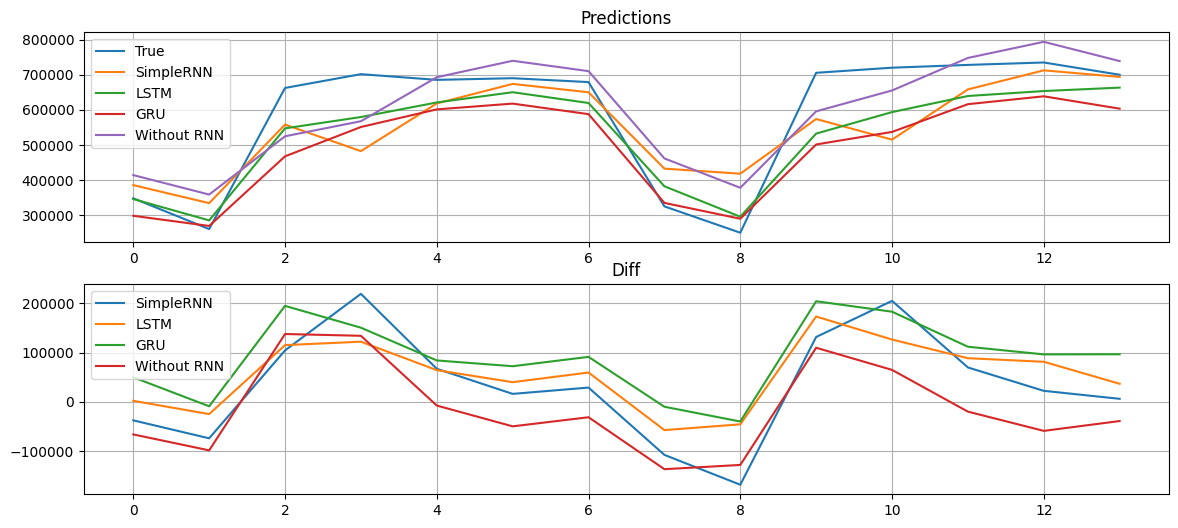

In [94]:
y_true = pd.Series(next(iter(downsampled_valid))[1][0][0].numpy()) * 1e6

simple_pred  = pd.Series(conv_SimpleRNN_model.predict(downsampled_valid)[0][0]) * 1e6
LSTM_pred    = pd.Series(conv_LSTM_model.predict(downsampled_valid)[0][0]) * 1e6
GRU_pred     = pd.Series(conv_GRU_model.predict(downsampled_valid)[0][0]) * 1e6
without_pred = pd.Series(conv_WithoutRNN_model.predict(downsampled_valid)[0][0]) * 1e6

simple_diff  = y_true - simple_pred
LSTM_diff    = y_true - LSTM_pred
GRU_diff     = y_true - GRU_pred
without_diff = y_true - without_pred

fig, ax = plt.subplots(2, 1, figsize=(14, 6))

y_true.plot(ax=ax[0], label='True')
simple_pred.plot(ax=ax[0], label='SimpleRNN')
LSTM_pred.plot(ax=ax[0], label='LSTM')
GRU_pred.plot(ax=ax[0], label='GRU')
without_pred.plot(ax=ax[0], label='Without RNN')

ax[0].set_title('Predictions')
ax[0].legend()
ax[0].grid()

simple_diff.plot(ax=ax[1], label='SimpleRNN')
LSTM_diff.plot(ax=ax[1], label='LSTM')
GRU_diff.plot(ax=ax[1], label='GRU')
without_diff.plot(ax=ax[1], label='Without RNN')

ax[1].set_title('Diff')
ax[1].legend()
ax[1].grid()

simple_mape  = np.abs(simple_diff / y_true).mean()
LSTM_mape    = np.abs(LSTM_diff / y_true).mean()
GRU_mape     = np.abs(GRU_diff / y_true).mean()
without_mape = np.abs(without_diff / y_true).mean()

simple_mae  = np.abs(simple_diff).mean()
LSTM_mae    = np.abs(LSTM_diff).mean()
GRU_mae     = np.abs(GRU_diff).mean()
without_mae = np.abs(without_diff).mean()

pd.DataFrame([
    [simple_mape, simple_mae, conv_SimpleRNN_fittime],
    [LSTM_mape, LSTM_mae, conv_LSTM_fittime],
    [GRU_mape, GRU_mae, conv_GRU_fittime],
    [without_mape, without_mae, conv_WithoutRNN_fittime],
], index=['SimpleRNN', 'LSTM', 'GRU', 'Wavenet'], columns=['MAPE', 'MAE', 'Fit Time'])

In [8]:
import nbformat

nb = nbformat.read("hw_137.ipynb", as_version=4)

if "widgets" in nb["metadata"]:
    del nb["metadata"]["widgets"]

nbformat.write(nb, "hw_137_fixed.ipynb")